In [22]:
# !pip install matplotlib
# !pip install seaborn

In [23]:
import pandas as pd
import seaborn as sns

titanic_df = pd.read_csv("titanic_data.csv")

### 1.Bar Chart

In [24]:
info_count = titanic_df.Survived.value_counts()
info_count

Survived
0    549
1    342
Name: count, dtype: int64

<Axes: title={'center': ' Count of Survived Passengers'}, xlabel='Survived (No = 0, Yes = 1)', ylabel='No. of Passengers'>

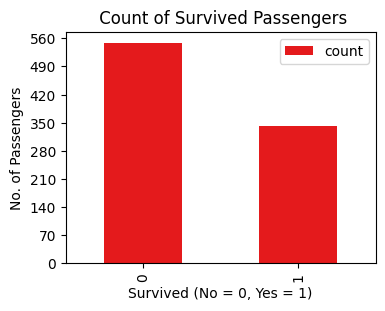

In [25]:
# info_count.plot(kind = "bar")
info_count.plot.bar(
    title = " Count of Survived Passengers",
    xlabel = "Survived (No = 0, Yes = 1)",
    ylabel = "No. of Passengers",
    yticks = list(range(0,600,70)),
    legend = True,
    colormap = "Set1",
    figsize = (4,3)
)

In [26]:
# sns.countplot(
#     data = titanic_df,
#     x = "Survived"
# )

In [27]:
titanic_df[["Sex", "Survived"]].value_counts()

Sex     Survived
male    0           468
female  1           233
male    1           109
female  0            81
Name: count, dtype: int64

[Text(0, 0, 'No'), Text(1, 0, 'Yes')]

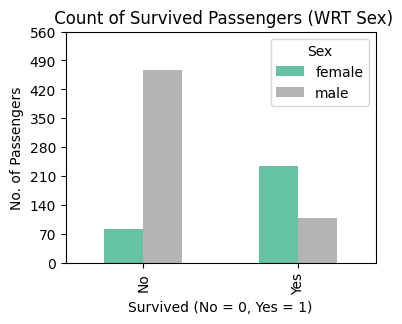

In [28]:
ax = pd.crosstab(
    titanic_df.Survived,
    titanic_df.Sex,
).plot.bar(
    title = " Count of Survived Passengers (WRT Sex)",
    xlabel = "Survived (No = 0, Yes = 1)",
    ylabel = "No. of Passengers",
    yticks = list(range(0,600,70)),
    legend = True,
    colormap = "Set2",
    figsize = (4,3)
)

# Change x-axis tick labels
ax.set_xticklabels(['No', 'Yes'], rotation=90)

## 2. Pie Chart

In [29]:
group_by_embarked = titanic_df.groupby(by = "Embarked")
counter = group_by_embarked.count()
counter

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin
Embarked,,,,,,,,,,,
C,168,168,168,168,168,130,168,168,168,168,69
Q,77,77,77,77,77,28,77,77,77,77,4
S,644,644,644,644,644,554,644,644,644,644,129


<Axes: >

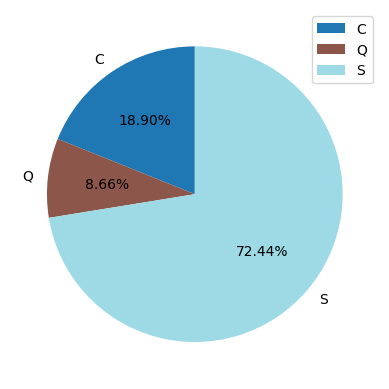

In [30]:
counter.plot(
    kind = "pie",
    y = "Survived",
    colormap="tab20",
    autopct = "%1.2f%%",
    startangle = 90
)

array([<Axes: >, <Axes: >], dtype=object)

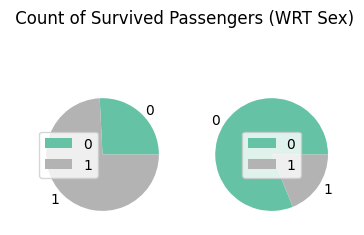

In [31]:
pd.crosstab(
    titanic_df.Survived,
    titanic_df.Sex,
).plot(
    kind = "pie",
    subplots=True,
    title = " Count of Survived Passengers (WRT Sex)",
    legend = True,
    colormap = "Set2",
    figsize = (4,3)
)

### 3. Histogram

<Axes: ylabel='Frequency'>

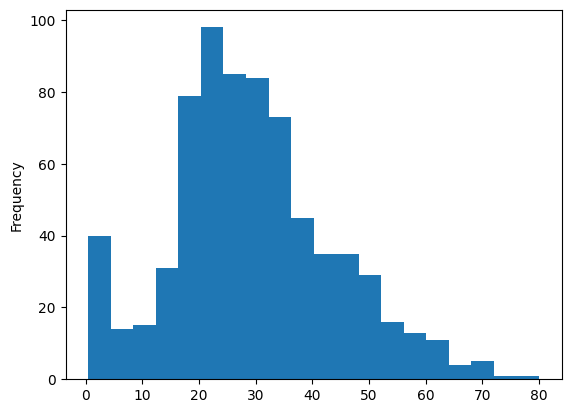

In [32]:
titanic_df.Age.plot(
    kind = "hist",
    bins = 20
)

array([<Axes: title={'center': 'female'}, ylabel='Frequency'>,
       <Axes: title={'center': 'male'}, ylabel='Frequency'>], dtype=object)

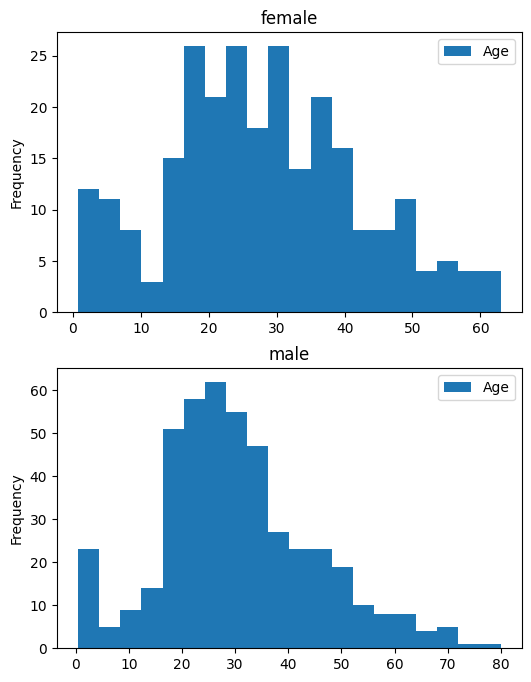

In [33]:
titanic_df[["Age", "Sex"]].plot(
    kind = "hist",
    by = "Sex",
    bins = 20,
    figsize=(6, 8)
)

<Axes: ylabel='Frequency'>

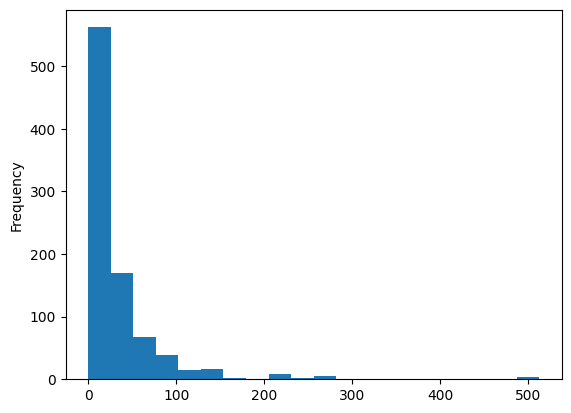

In [34]:
titanic_df["Fare"].plot(
    kind = "hist",
    bins = 20
)

<Axes: ylabel='Density'>

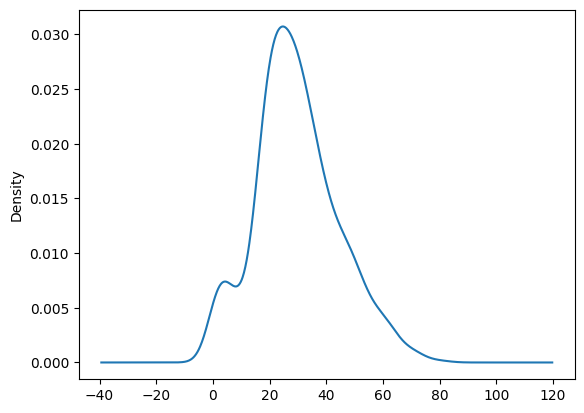

In [35]:
# !pip install scipy

titanic_df["Age"].plot(
    kind = "kde",
)

## 4. Scatter Plot

<Axes: xlabel='Age', ylabel='Fare'>

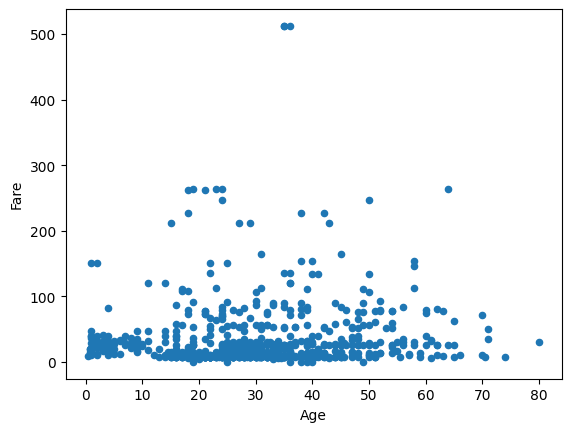

In [36]:
titanic_df.plot(
    kind="scatter",
    x = "Age", y = "Fare"
)

<Axes: xlabel='Age', ylabel='Fare'>

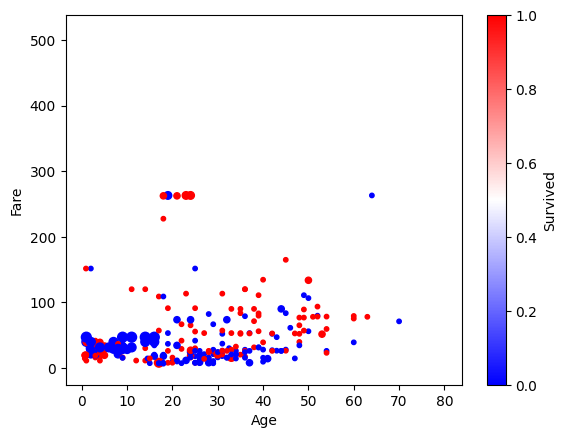

In [38]:
titanic_df.plot(
    kind="scatter",
    x = "Age", y = "Fare",
    c = "Survived",
    s = "SibSp",
    colormap="bwr"
)

## 5. Line Chart

<Axes: xlabel='age'>

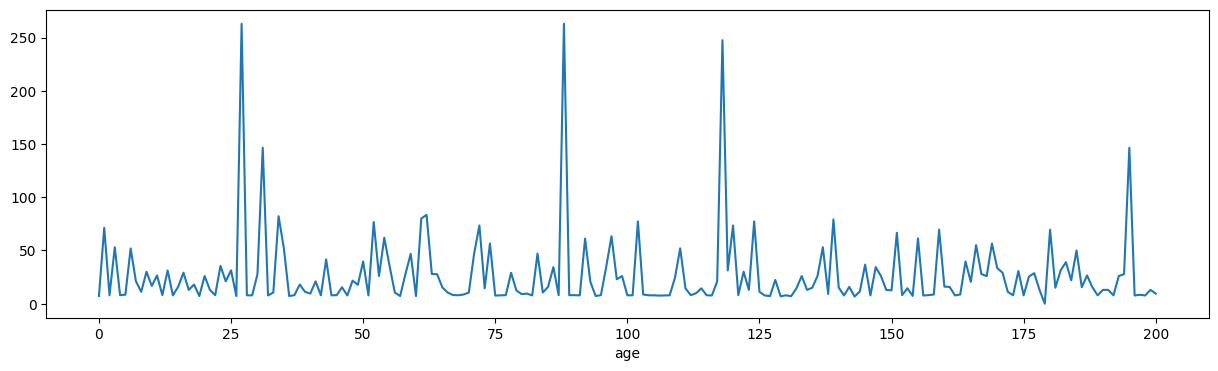

In [ ]:
titanic_df.Fare.loc[:200].plot(
    kind = "line",
    xlabel="age",
    figsize=(15,4)
)

<Axes: >

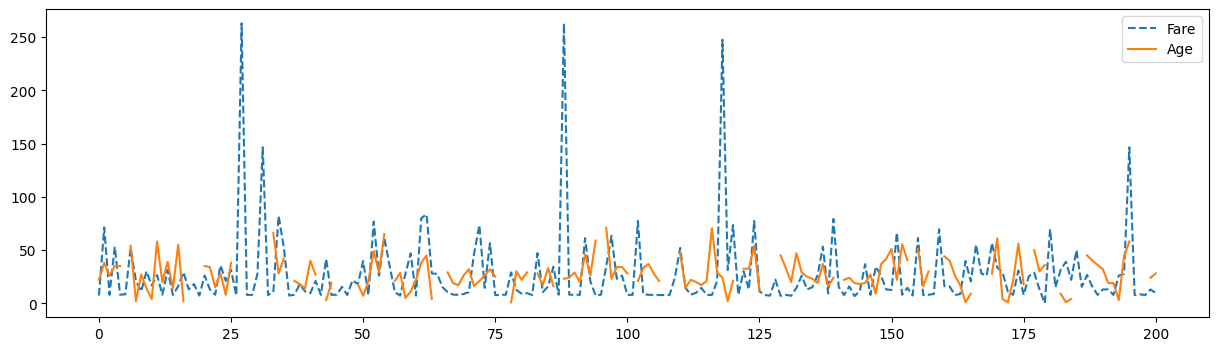

In [49]:
titanic_df[["Fare","Age"]].loc[:200].plot(
    kind = "line",
    figsize=(15,4),
    style=["--", "-"]
)

### 6. Box Plot

https://online-learning-college.com/wp-content/uploads/2022/04/Interquartile-range-scaled.jpg

In [52]:
titanic_df.Age.describe()

count    714.000000
mean      29.699118
std       14.526497
min        0.420000
25%       20.125000
50%       28.000000
75%       38.000000
max       80.000000
Name: Age, dtype: float64

<Axes: >

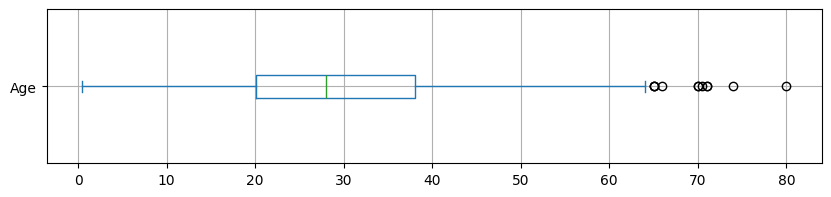

In [51]:
titanic_df.plot(kind="box", column = "Age", grid=True, vert = False, figsize=(10,2))

<Axes: >

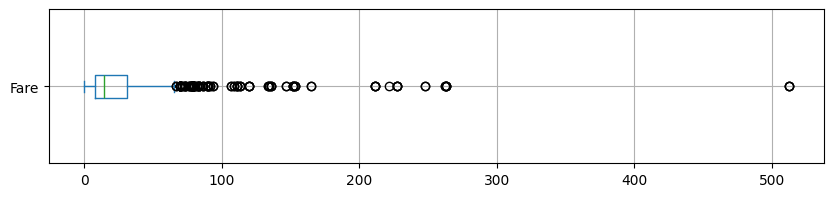

In [53]:
titanic_df.plot(kind="box", column = "Fare", grid=True, vert = False, figsize=(10,2))

Age    Axes(0.125,0.11;0.775x0.77)
dtype: object

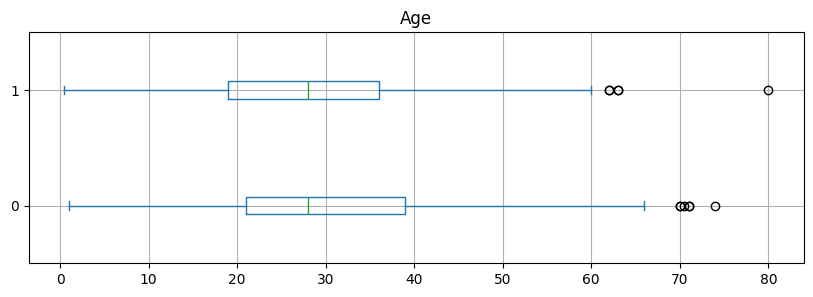

In [59]:
titanic_df.plot(kind="box", column = "Age", by= "Survived", grid=True, vert = False, figsize=(10,3))

## 7. Heat Map

In [60]:
correlation = titanic_df.corr(numeric_only=True)
correlation

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
PassengerId,1.000000,-0.005007,-0.035144,0.036847,-0.057527,-0.001652,0.012658
Survived,-0.005007,1.000000,-0.338481,-0.077221,-0.035322,0.081629,0.257307
Pclass,-0.035144,-0.338481,1.000000,-0.369226,0.083081,0.018443,-0.549500
Age,0.036847,-0.077221,-0.369226,1.000000,-0.308247,-0.189119,0.096067
SibSp,-0.057527,-0.035322,0.083081,-0.308247,1.000000,0.414838,0.159651
Parch,-0.001652,0.081629,0.018443,-0.189119,0.414838,1.000000,0.216225
Fare,0.012658,0.257307,-0.549500,0.096067,0.159651,0.216225,1.000000


<Axes: >

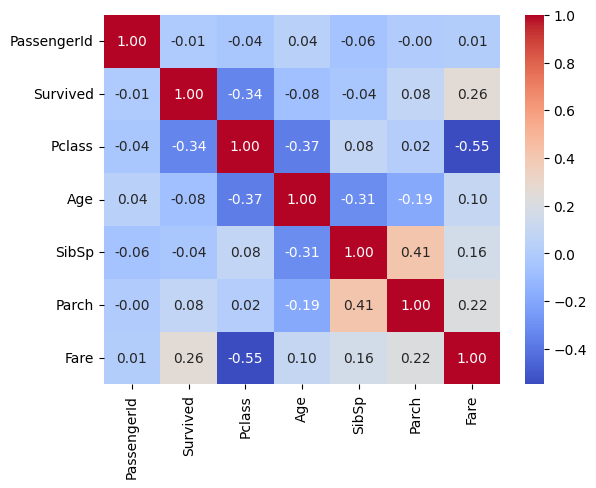

In [64]:
sns.heatmap(
    data= correlation, 
    annot= True,
    fmt = ".2f",
    cmap="coolwarm"
)

<Axes: xlabel='Age'>

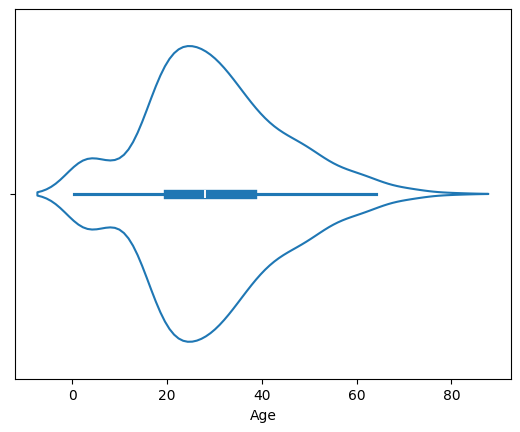

In [ ]:
# Violin Plot
sns.violinplot(x = titanic_df.Age, orient="h", fill=False)

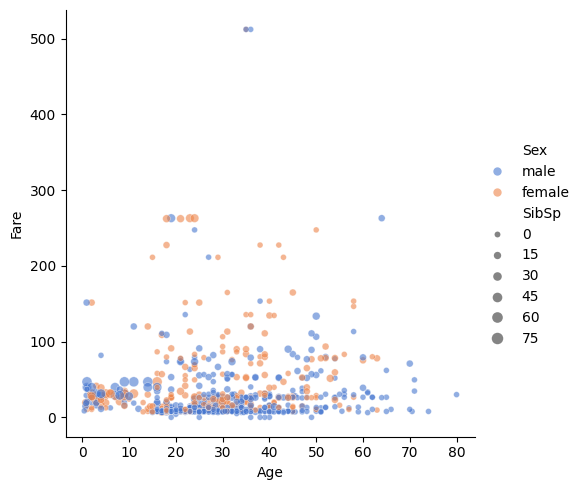

In [75]:
# Bubble Chart

sns.relplot(
    data=titanic_df,
    x = "Age", y ="Fare",
    size = "SibSp",
    hue = "Sex",
    palette = "muted",
    alpha = 0.6
)

<Axes: >

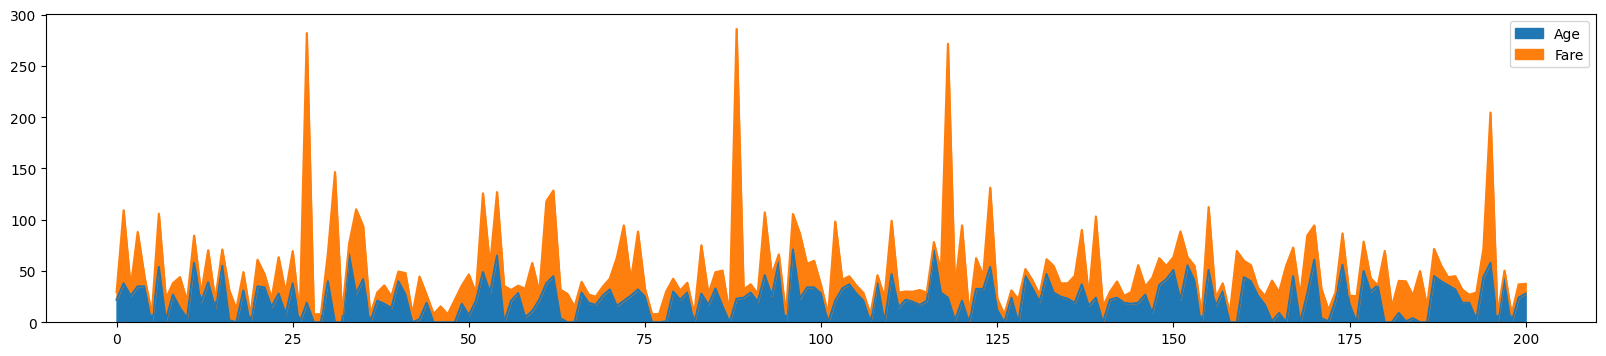

In [80]:
# Area Plot

titanic_df[["Age","Fare"]].loc[:200].plot(
    kind = "area",
    figsize=(20,4)
)